In [3]:
import pandas as pd 
from sklearn.model_selection import train_test_split


In [4]:
expr = pd.read_csv("TCGA.BRCA.sampleMap_HiSeqV2", sep="\t")
expr = expr.set_index("sample")
x = expr.T

In [5]:
clinical = pd.read_csv("TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", sep="\t")
clinical2 = clinical.set_index("sampleID")

y = clinical2.loc[x.index, "PAM50Call_RNAseq"]

In [6]:
valid = y.notna()
x = x.loc[valid]
y = y.loc[valid]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [7]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
rf_model = RandomForestClassifier(n_jobs=-1, random_state=42)
param_grid = {'n_estimators': [100, 200, 500], 'max_depth': [None, 10, 20]}

In [10]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold 
from sklearn.ensemble import RandomForestClassifier
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [11]:
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_g

In [13]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV SCore:", grid_search.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV SCore: 0.879609563123495


In [14]:
rf_best = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_best.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [15]:
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score)
y_pred = rf_best.predict(x_test)
y_prob = rf_best.predict_proba(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nMacro AUC:")
print(roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro"))

Accuracy: 0.8854166666666666

Classification Report:
              precision    recall  f1-score   support

       Basal       1.00      1.00      1.00        29
        Her2       0.89      0.62      0.73        13
        LumA       0.87      0.97      0.91        87
        LumB       0.81      0.74      0.77        39
      Normal       0.95      0.83      0.89        24

    accuracy                           0.89       192
   macro avg       0.90      0.83      0.86       192
weighted avg       0.89      0.89      0.88       192

Confusion Matrix:
[[29  0  0  0  0]
 [ 0  8  0  5  0]
 [ 0  0 84  2  1]
 [ 0  0 10 29  0]
 [ 0  1  3  0 20]]

Macro AUC:
0.9834086836063319


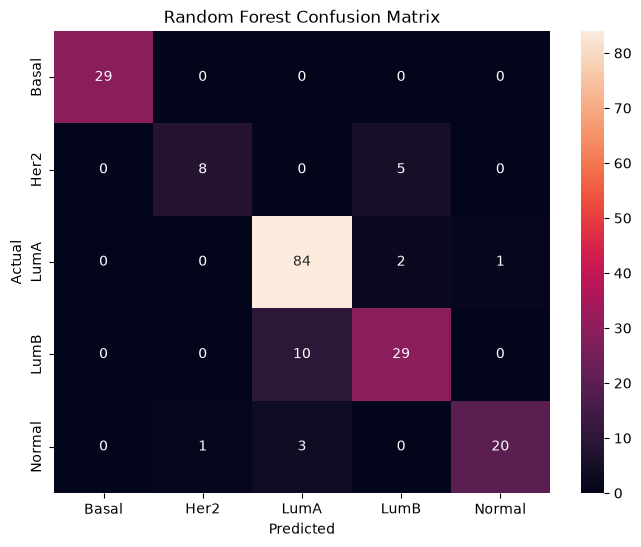

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=rf_best.classes_, yticklabels=rf_best.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.savefig("Random Forest Confusion Matrix", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
importance = pd.Series(rf_best.feature_importances_, index=x_train.columns).sort_values(ascending=False)
top20_gene = importance.head(20)
print(top20_gene)

sample
TBC1D9    0.008504
ROPN1B    0.005382
ASPM      0.005215
VGLL1     0.005043
STAC      0.004521
TRIM29    0.004242
TPX2      0.004098
CENPA     0.003890
BBOX1     0.003851
TTK       0.003838
UBE2T     0.003744
FOXC1     0.003526
DEGS2     0.003438
FAM72B    0.003409
MRAS      0.003294
ACADSB    0.003207
ESPL1     0.003197
SFRP1     0.003149
CCNA2     0.003140
FAM54A    0.003087
dtype: float64


#Biological Interpretation of Top 20 Important Genes

The Random Forest model identified 20 genes that contributed most to the classification of breast cancer samples into PAM50 molecular subtypes. These genes should be interpreted as important predictive features of the model rather than as direct causes of breast cancer.

Several of the top-ranked genes are associated with cell-cycle regulation, mitosis, chromosome segregation, and cellular proliferation. For example, ASPM is involved in mitotic spindle organization and cell division, and elevated ASPM expression has been associated with highly proliferative and more aggressive breast cancer characteristics. TPX2, CENPA, TTK, ESPL1, and CCNA2 are also involved in processes related to mitosis, chromosome segregation, or cell-cycle progression. The presence of several genes from these biological processes suggests that differences in cellular proliferation and cell-cycle activity contribute to the molecular differences captured by the classifier.

Other genes provide information about cellular regulation and breast cancer biology. FOXC1 is a transcription factor associated with basal-like/triple-negative breast cancer biology, while SFRP1 is involved in Wnt-related signaling and has been reported to show altered expression in breast cancer. TRIM29 has also been studied in breast cancer and can have context-dependent effects; studies have reported a tumor-suppressive role in certain breast epithelial and ER-positive breast cancer settings.

In a nutshell, the top 20 genes suggest that the Random Forest is detecting biological differences related mainly to cell proliferation, mitotic activity, chromosome regulation, transcriptional control, and signaling pathways. This is biologically plausible because PAM50 breast cancer subtypes differ in their molecular expression patterns and proliferative characteristics. However, these feature-importance results alone do not establish that every gene is a subtype-specific biomarker or a causal driver of the disease. Further differential-expression and pathway-enrichment analyses would be required to confirm the biological significance of these genes.
 

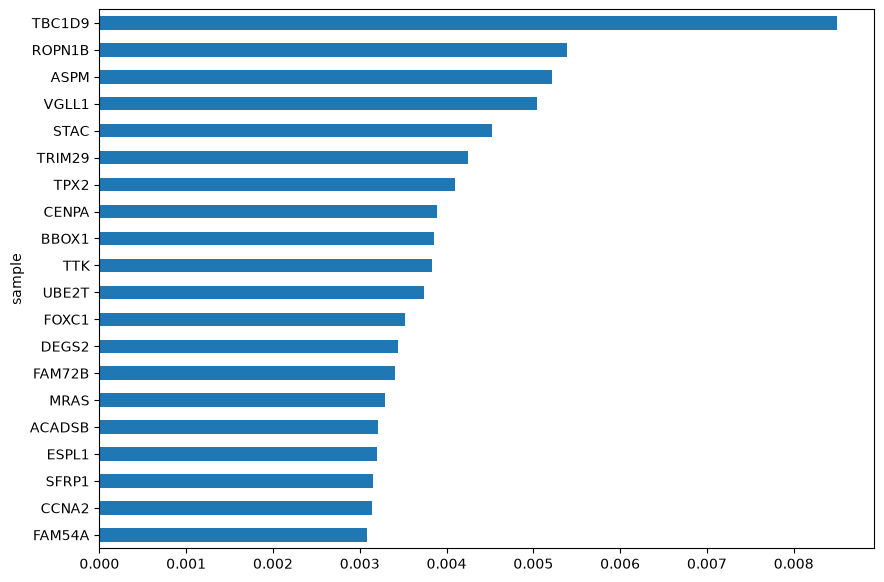

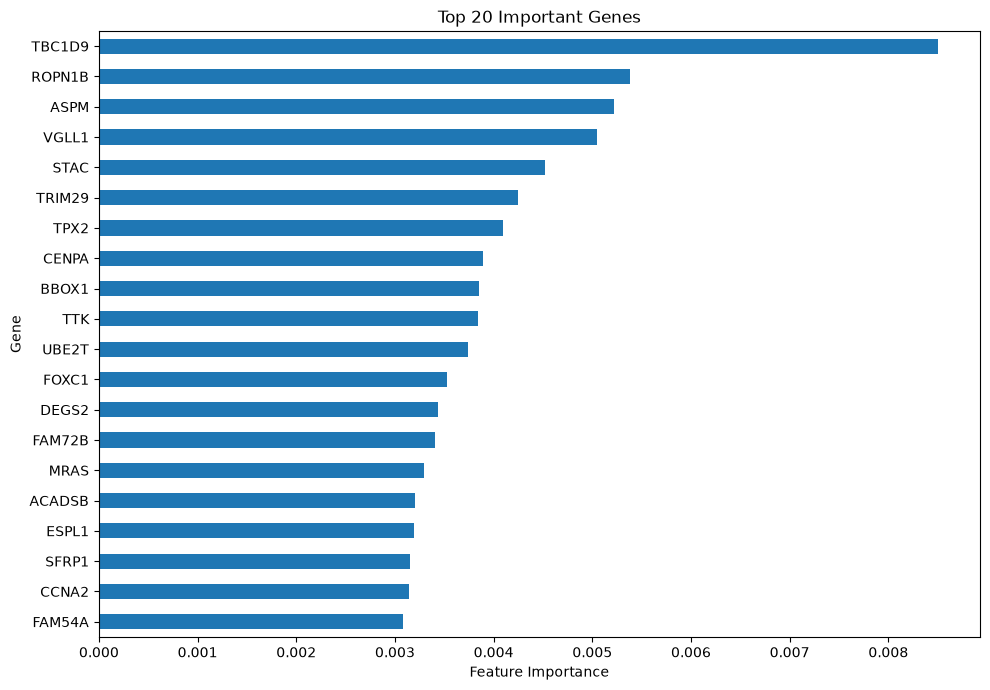

In [28]:
plt.figure(figsize=(10, 7))
top20_gene.sort_values().plot(kind="barh")

plt.figure(figsize=(10, 7))

top20_gene.sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.ylabel("Gene")
plt.title("Top 20 Important Genes")
plt.tight_layout()
plt.savefig("Top 20 Important Genes", dpi=300, bbox_inches="tight")
plt.show()

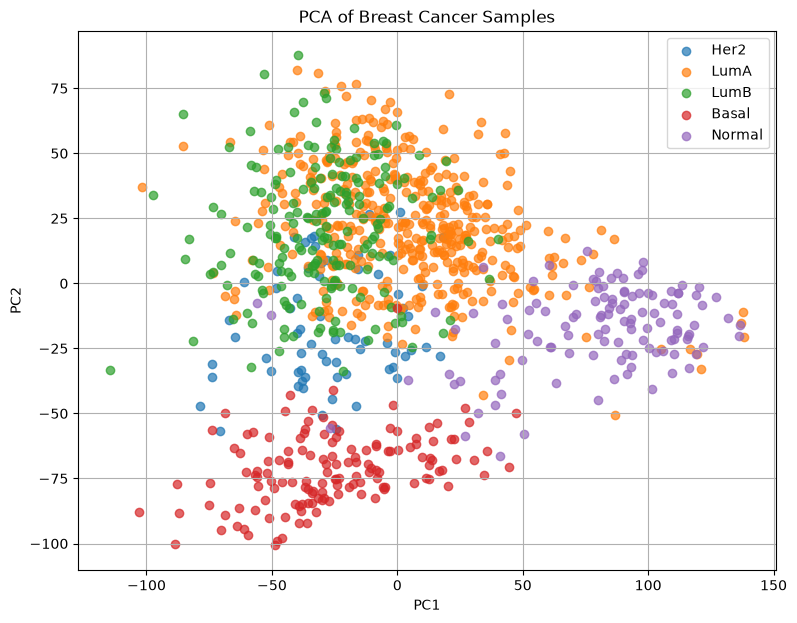

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
plt.figure(figsize=(9, 7))

for subtype in y.unique():
    mask = y == subtype
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1], label=subtype, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Breast Cancer Samples")
plt.legend()
plt.grid(True)
plt.savefig("PCA of Breast Cancer Samples", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
import warnings
warnings.filterwarnings("ignore", message="n_jobs value 1 overridden to 1 by setting random_state")

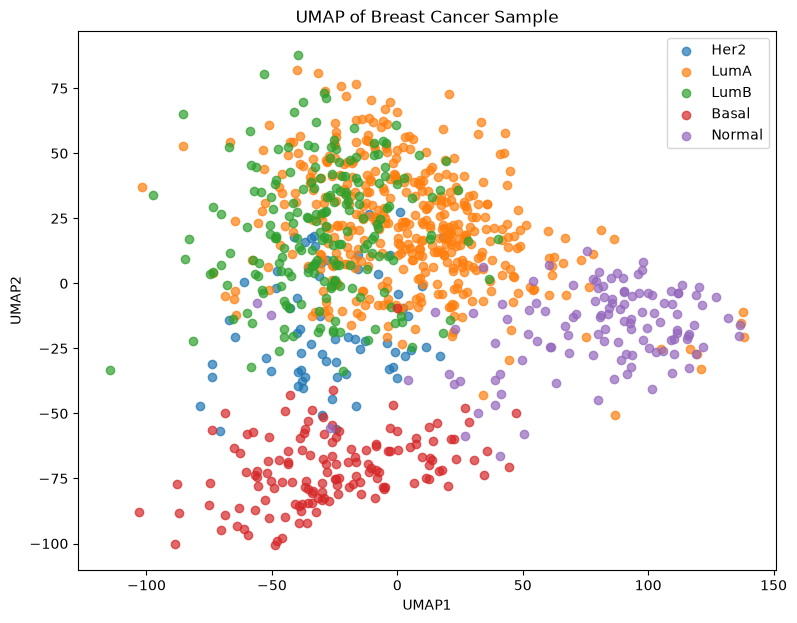

In [25]:
import umap.umap_ as umap
reducer = umap.UMAP(n_components=2, random_state=42)
x_umap = reducer.fit_transform(x_scaled)

plt.figure(figsize=(9, 7))

for subtype in y.unique():
    mask = y == subtype
    plt.scatter(x_pca[mask, 0], x_pca[mask, 1], label=subtype, alpha=0.7)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP of Breast Cancer Sample")
plt.legend()
plt.savefig("UMAP of Breast Cancer Sample", dpi=300, bbox_inches="tight")
plt.show()